# BTSP in a T-maze

* T-maze, largely fixed direction navigation, randomly selecting target arm on each trajectory
* CA3: 40 preset place fields
* CA1: 
  * Hebbian learning + BTSP learning at targeted neurons
  * BTSP learning: long-tailed (pre) Hebbian learning with a high output firing rate considered (occurs in one trajectory only)
  * (1) 1 cell, receives BTSP signal at a reward location

Evaluate resulting CA1 neuron place field properties

In [1]:
import copy
from typing import Any
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox
from tqdm import tqdm

from predhpc import agent, env, run_manager, plot_util, util, params_util
from predhpc.neurons import learning_neurons, two_comp_neurons, object_neurons

In [2]:
plot_util.stylize_plots_for_notebook()
ratinabox.autosave_plots = False
ratinabox.figure_directory = "figures"

In [3]:
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

## Reload

In [4]:
import importlib
importlib.reload(agent)
importlib.reload(env)
importlib.reload(learning_neurons)
importlib.reload(two_comp_neurons)
importlib.reload(object_neurons)
importlib.reload(run_manager)
importlib.reload(plot_util)
importlib.reload(util)
importlib.reload(params_util);

## T-maze BTSP

 88%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████▊               | 7037/8000 [00:06<00:00, 1084.80it/s]


Trajectory lengths (12) to date: 17.59 +/- 0.88 sec each
Trajectory lengths (12) to date: 586.50 +/- 29.36 steps each


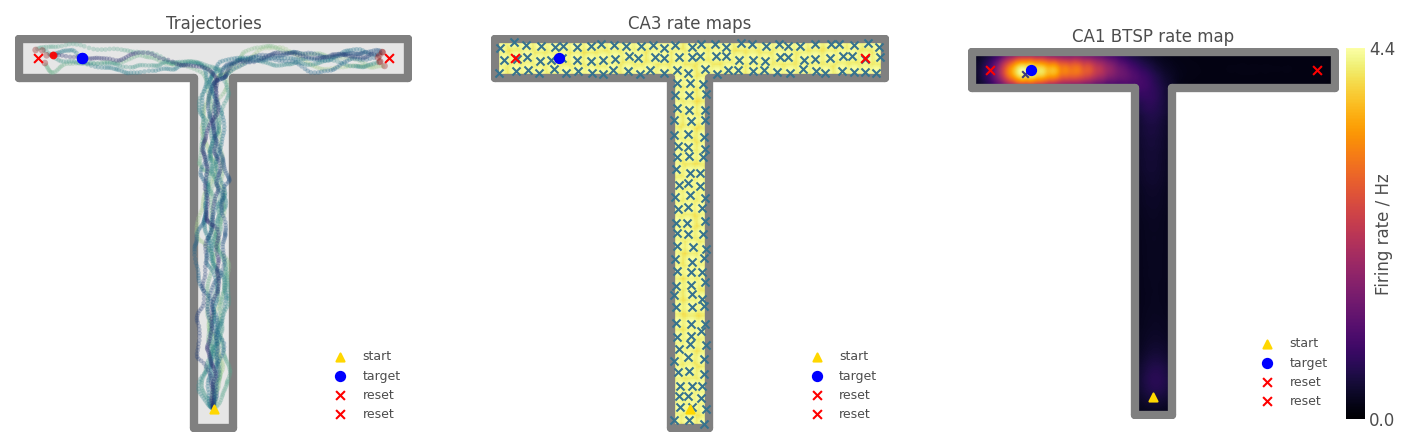

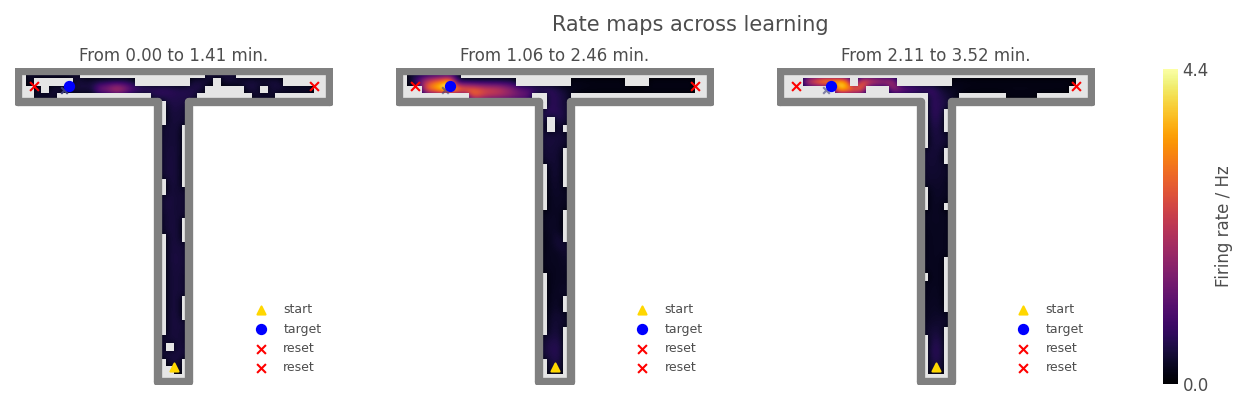

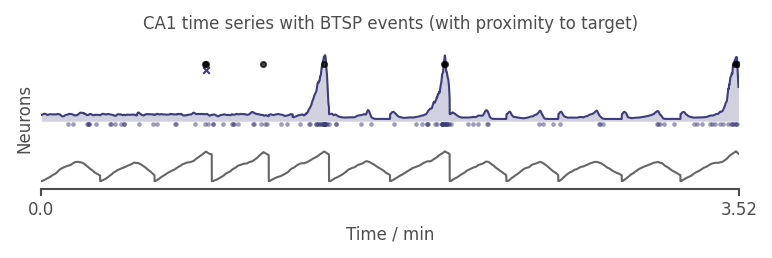

In [5]:
CA3_PC_params = params_util.get_CA3_PC_params(
    environment="tmaze", 
    n=177, # 40, # for one column and one row 
    place_cell_centres="uniform_jitter",
)

Env, Ag, _, CA3_PCs, CA1s = run_manager.learn_T_maze_BTSP(
    CA3_PC_params=CA3_PC_params,
    num_rewards=8, 
    max_num_steps=8000, 
    weight_recording_freq=100, 
    use_Hebbian=False,
    BTSP_after_num_target_reaches=2,
    two_compartment=False
)

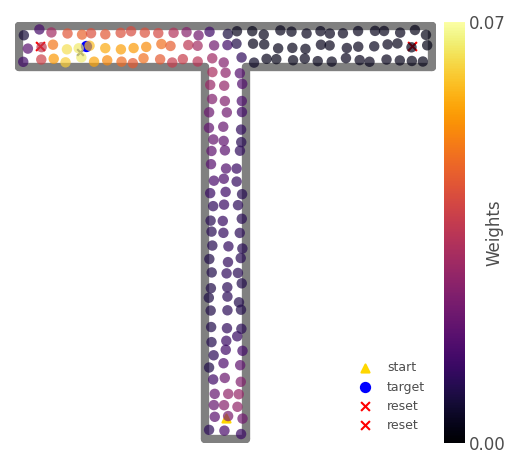

In [6]:
fig, ax = plt.subplots(figsize=[3, 3])
plot_util.plot_2D_input_place_cell_weights(CA1s, ax=ax, s=25, plot_BTSP_events=True);

## Distance to target

8


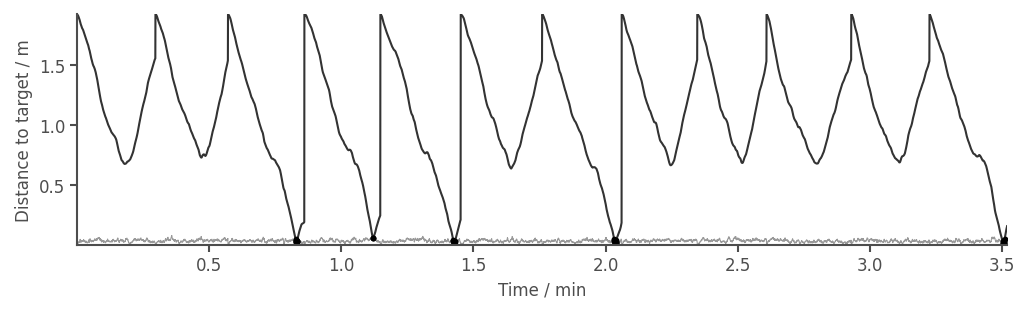

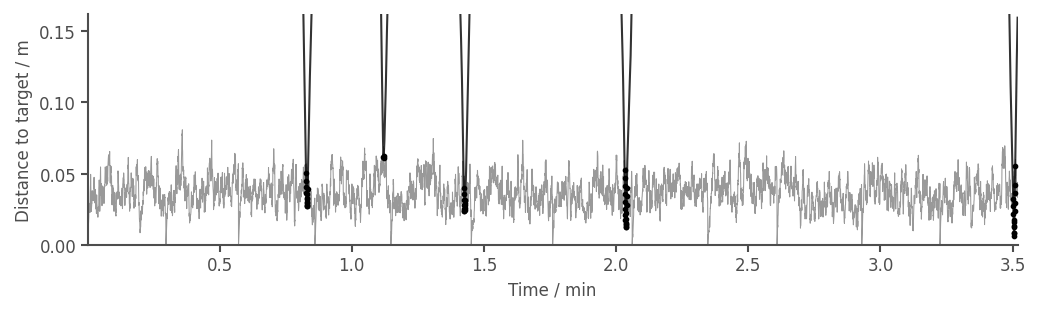

In [7]:
Ag.plot_distance_to(mark_below_tolerance=True)
Ag.plot_distance_to(zoom_prop=2, mark_below_tolerance=True)
print(Ag.target_reached_within_tol_prop_to_speed_dt)

## BTSP filtered inputs

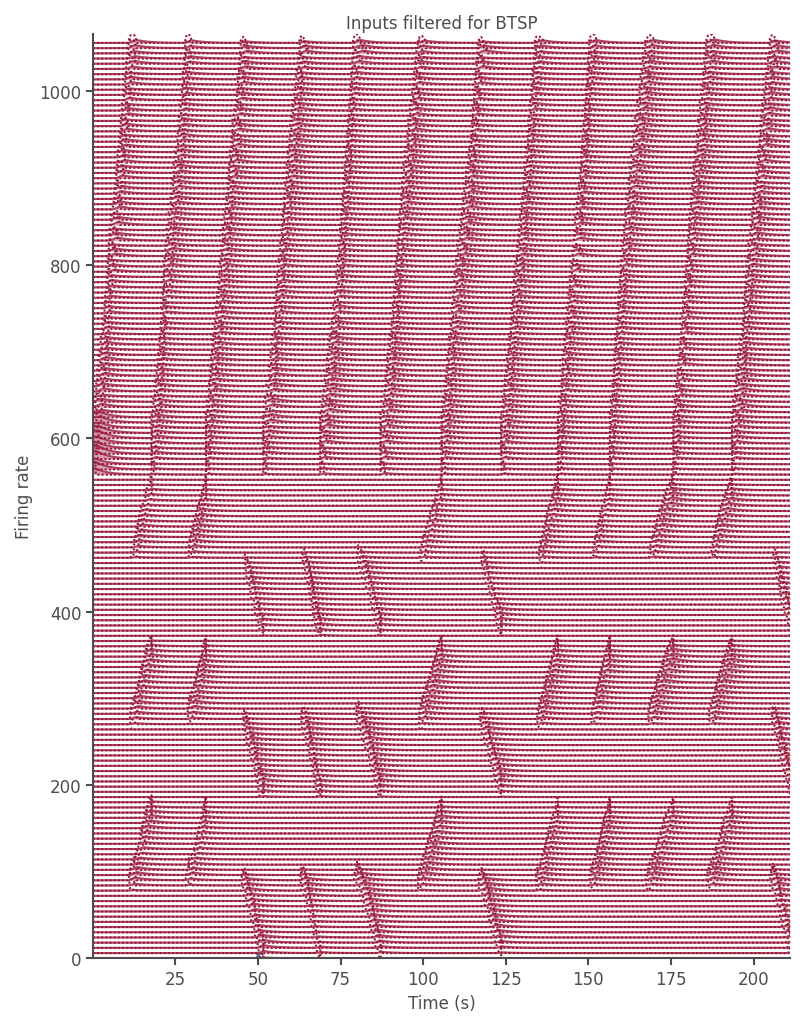

In [8]:
CA1s.plot_filtered_for_BTSP("CA3_PCs");

# BTSP 2-compartment independent

In [9]:
import importlib
importlib.reload(learning_neurons)
importlib.reload(two_comp_neurons)
importlib.reload(object_neurons)
importlib.reload(run_manager)
importlib.reload(plot_util)
importlib.reload(agent)
importlib.reload(env)

from tqdm import tqdm

In [10]:
DT = params_util.DT

env_params = params_util.get_env_params(environment="tmaze")

Ag_params = params_util.get_agent_params(
    environment="tmaze", dt=DT, left_arm_prop=0.8
)

CA3_PC_params = params_util.get_CA3_PC_params(
    environment="tmaze", place_cell_centres="uniform"
)

CA1_params = params_util.get_CA1_params(
    n=1, environment="tmaze", 
    two_compartment=True, BTSP=True,
    soma_BTSP_lr_fact=400,
)

 89%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████              | 3562/4000 [00:05<00:00, 651.45it/s]


Trajectory lengths (6) to date: 17.81 +/- 0.61 sec each
Trajectory lengths (6) to date: 593.83 +/- 20.37 steps each


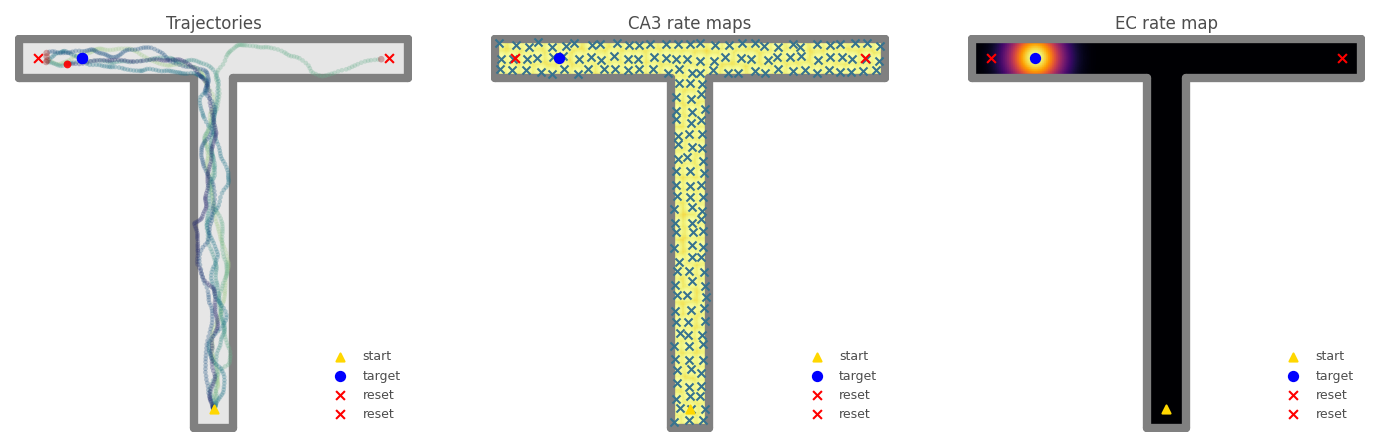

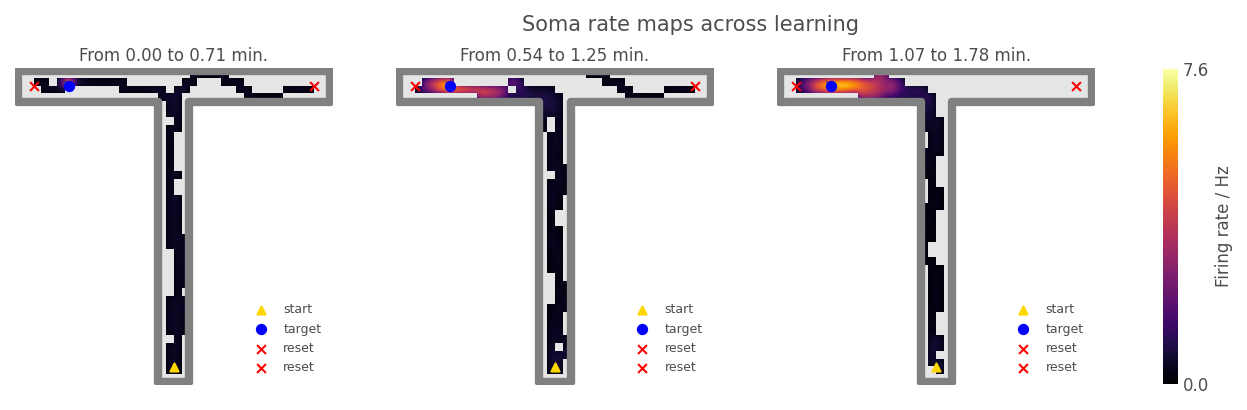

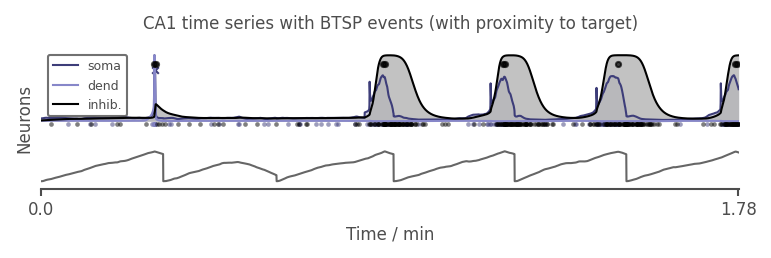

In [11]:
CA3_PC_params = params_util.get_CA3_PC_params(
    environment="tmaze", 
    n=177, # 40, # for one column and one row 
    place_cell_centres="uniform_jitter"
)

Env, Ag, ECs, CA3_PCs, CA1s = run_manager.learn_T_maze_BTSP(
    env_params, 
    Ag_params, 
    CA3_PC_params, 
    CA1_params, 
    num_rewards=8, 
    max_num_steps=4000, 
    weight_recording_freq=100, 
    use_Hebbian=False,
    BTSP_after_num_target_reaches=2, # ignored if 2-compartment
    two_compartment=True
)

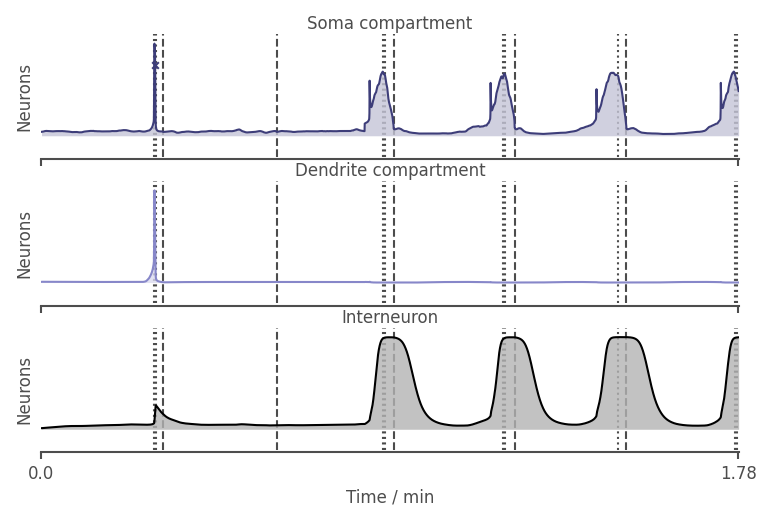

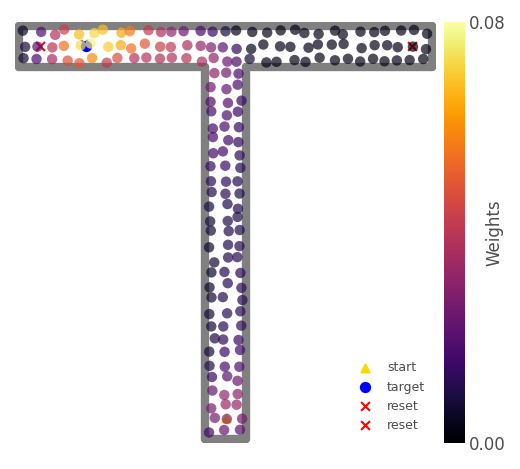

In [12]:
CA1s.plot_rate_timeseries(separate_axes=True)

fig, ax = plt.subplots(figsize=[3, 3])
plot_util.plot_2D_input_place_cell_weights(CA1s.SomaCompartment, ax=ax, s=25, plot_BTSP_events=True);

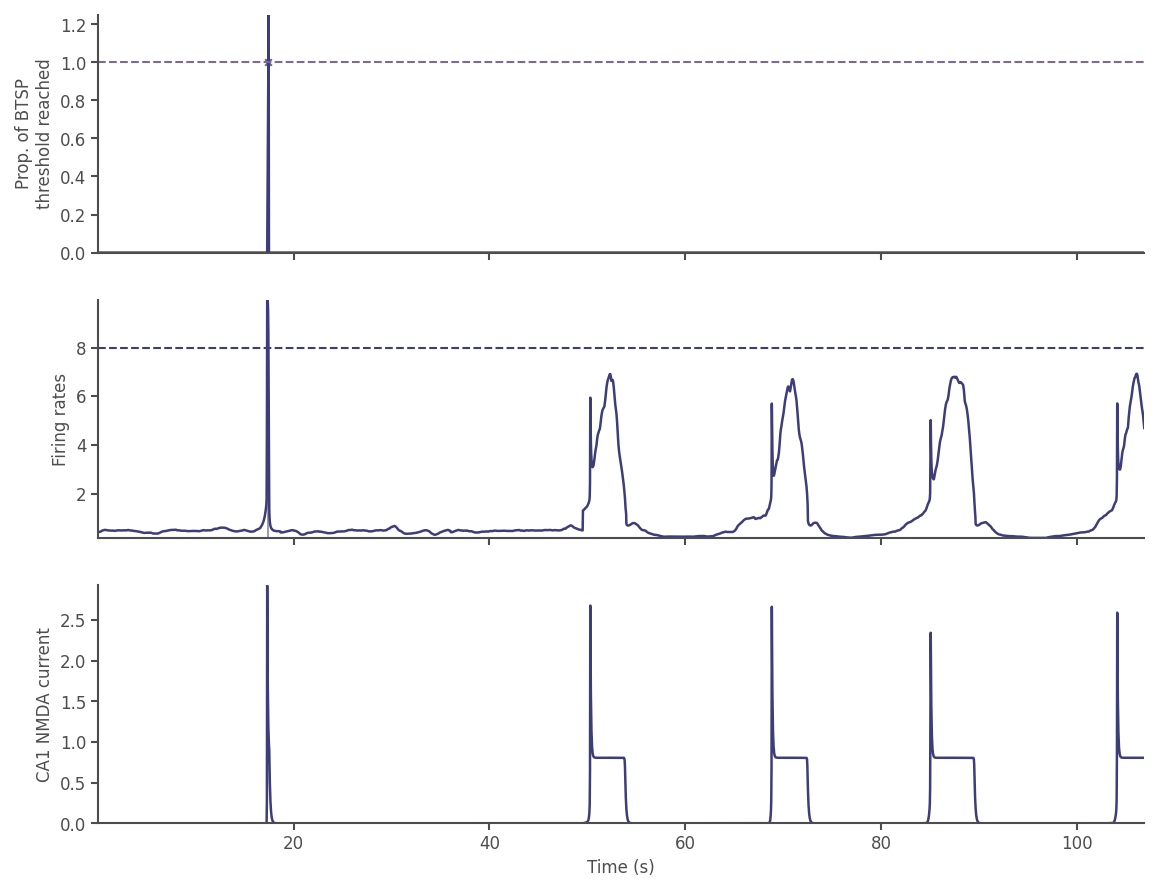

In [13]:
CA1s.SomaCompartment.plot_BTSP_ramp();

BTSP events applied after 1072.00 steps (32.16 sec.) (num steps: 1072).


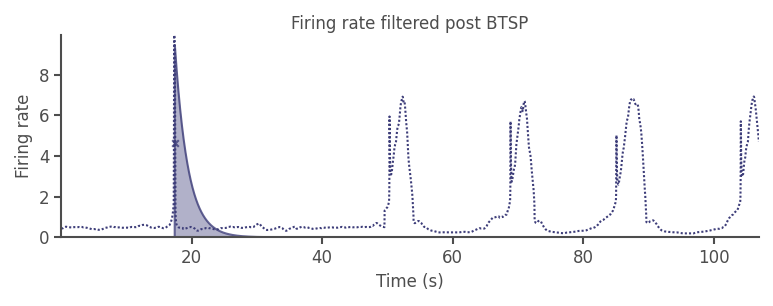

In [14]:
CA1s.SomaCompartment.log_num_steps_to_apply_BTSP()
CA1s.SomaCompartment.plot_filtered_for_BTSP();

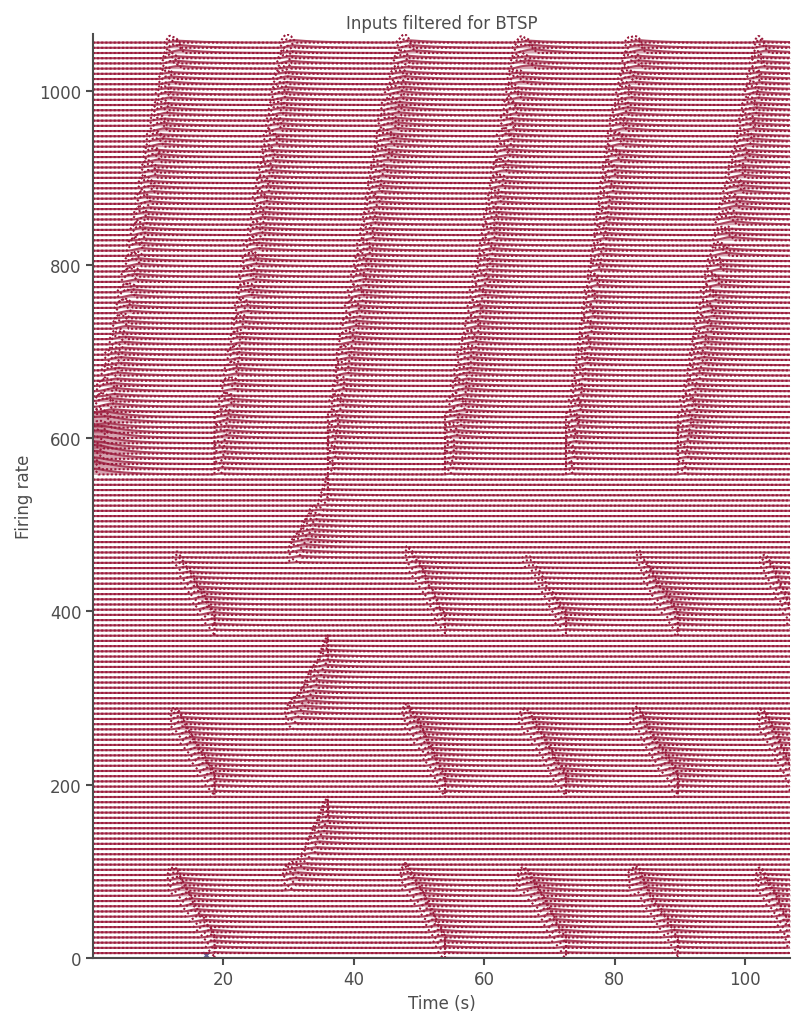

In [15]:
CA1s.SomaCompartment.plot_filtered_for_BTSP("CA3_PCs");

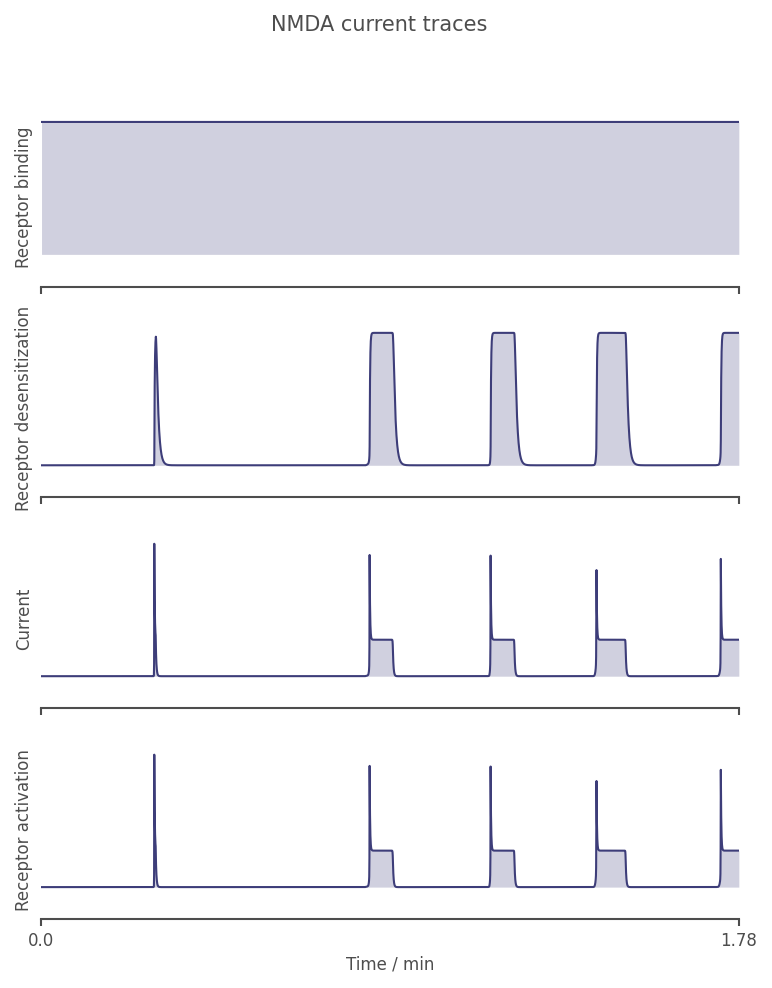

In [16]:
CA1s.SomaCompartment.inputs["NMDACurrent"]["layer"].plot_timeseries(datatypes="all");

In [17]:
Ag.target_df

,target_arm,position_x,position_y,set_step,set_time,reached_step,reached_time,num_steps_total,time_total
0,left,0.325,1.9,0,0.00,574.0,17.22,574.0,17.22
1,left,0.325,1.9,574,17.22,585.0,17.55,11.0,0.33
2,left,0.325,1.9,585,17.55,1746.0,52.38,1161.0,34.83
3,left,0.325,1.9,1746,52.38,1757.0,52.71,11.0,0.33
4,left,0.325,1.9,1757,52.71,2357.0,70.71,600.0,18.00
5,left,0.325,1.9,2357,70.71,2368.0,71.04,11.0,0.33
6,left,0.325,1.9,2368,71.04,2947.0,88.41,579.0,17.37
7,left,0.325,1.9,2947,88.41,3541.0,106.23,594.0,17.82
8,left,0.325,1.9,3541,106.23,3552.0,106.56,11.0,0.33
9,left,0.325,1.9,3552,106.56,NaN,NaN,NaN,NaN


In [18]:
Ag.trajectory_df

,start_position_x,start_position_y,start_step,start_time,stop_position_x,stop_position_y,stop_step,stop_time,num_steps_total,time_total
0,1.000244,0.099663,0,0.00,0.142826,1.923284,622.0,18.66,622.0,18.66
1,1.000462,0.100578,622,18.66,1.861608,1.923284,1201.0,36.03,579.0,17.37
2,0.999535,0.099280,1201,36.03,0.137465,1.923284,1799.0,53.97,598.0,17.94
3,1.000254,0.099769,1799,53.97,0.142024,1.923284,2417.0,72.51,618.0,18.54
4,1.000874,0.099904,2417,72.51,0.129983,1.923284,2988.0,89.64,571.0,17.13
5,1.001109,0.100436,2988,89.64,NaN,NaN,NaN,NaN,NaN,NaN


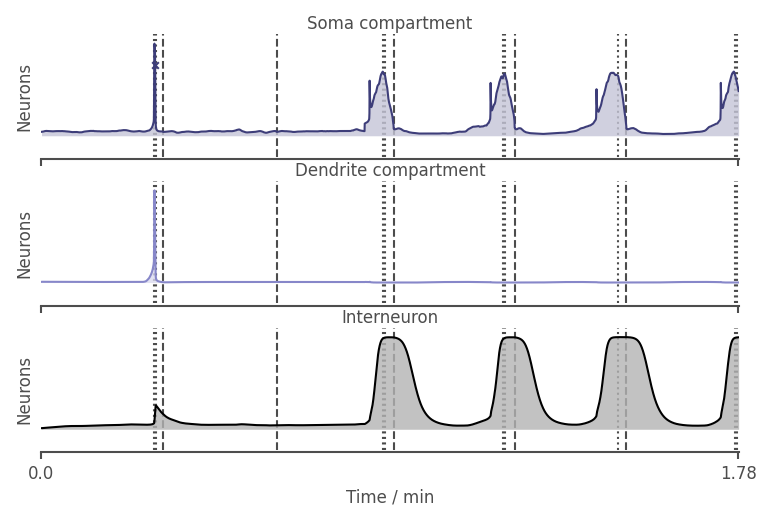

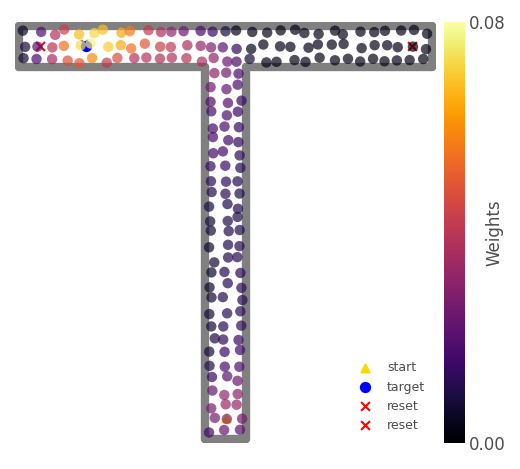

In [19]:
ax_time = CA1s.plot_rate_timeseries(separate_axes=True)

fig_weights, ax_weights = plt.subplots(figsize=[3, 3])
plot_util.plot_2D_input_place_cell_weights(CA1s.SomaCompartment, ax=ax_weights, s=25, plot_BTSP_events=True);

## Move target

In [20]:
Ag.set_target_position([1, 1.3])

In [21]:
num_steps = 2500
for i in tqdm(range(2500)):
    Ag.update(speed_fact=3, drift_to_random_strength_ratio=1)
    ECs.update()
    CA3_PCs.update()
    CA1s.update()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2500/2500 [00:03<00:00, 672.42it/s]


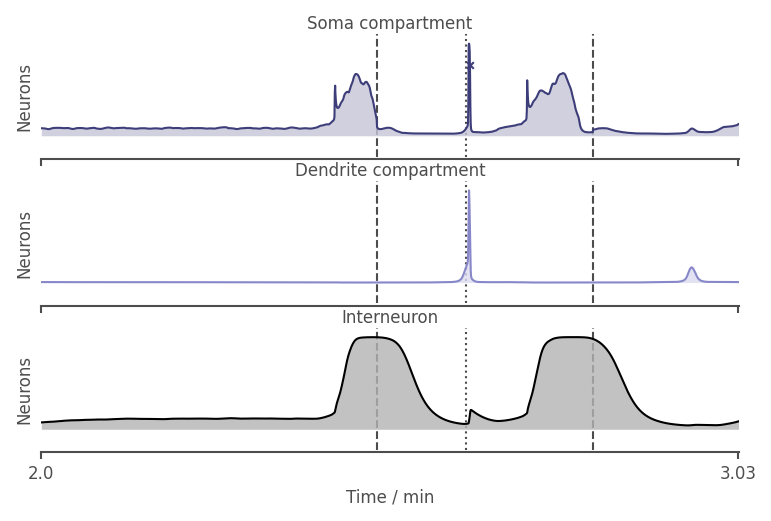

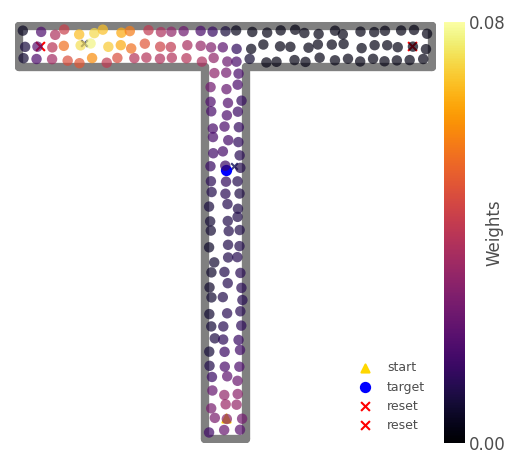

In [22]:
ax_time = CA1s.plot_rate_timeseries(t_start=2*60, separate_axes=True)

fig_weights, ax_weights = plt.subplots(figsize=[3, 3])
plot_util.plot_2D_input_place_cell_weights(CA1s.SomaCompartment, ax=ax_weights, s=25, plot_BTSP_events=True);

## Wrong parameters

In [23]:
INHIBIT_WEIGHT = 0.5 # too low

In [24]:
DT = params_util.DT

env_params = params_util.get_env_params(environment="tmaze")

Ag_params = params_util.get_agent_params(
    environment="tmaze", dt=DT, left_arm_prop=0.8
)

CA3_PC_params = params_util.get_CA3_PC_params(
    environment="tmaze", place_cell_centres="uniform"
)

CA1_params = params_util.get_CA1_params(
    n=1, environment="tmaze", 
    two_compartment=True, BTSP=True,
    soma_BTSP_lr_fact=400,
    inhibit_weight=INHIBIT_WEIGHT
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6000/6000 [00:09<00:00, 662.34it/s]


Only reached the reward 7 times (target: 12).
Trajectory lengths (10) to date: 18.00 +/- 0.74 sec each
Trajectory lengths (10) to date: 600.00 +/- 24.73 steps each


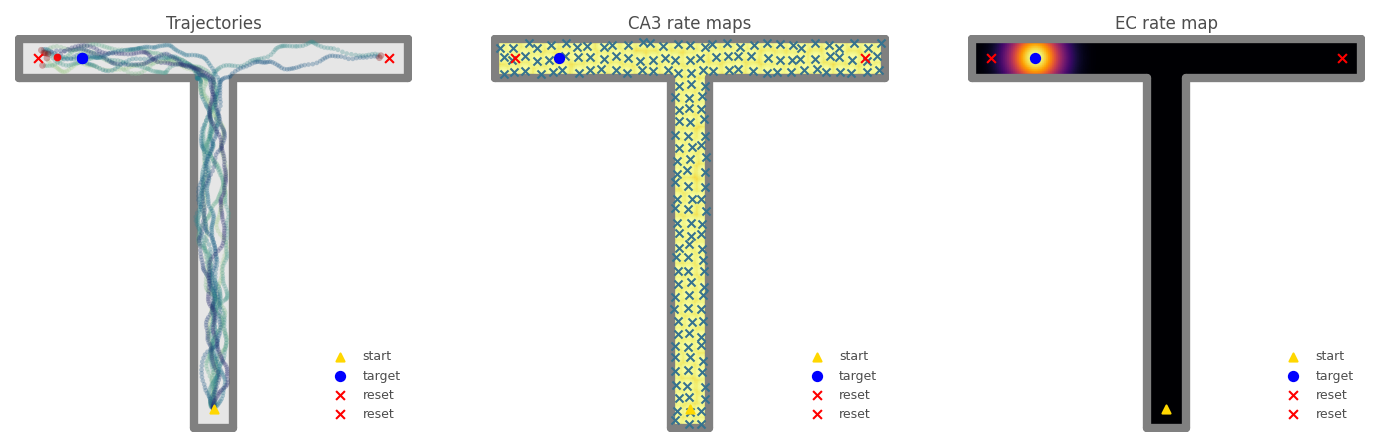

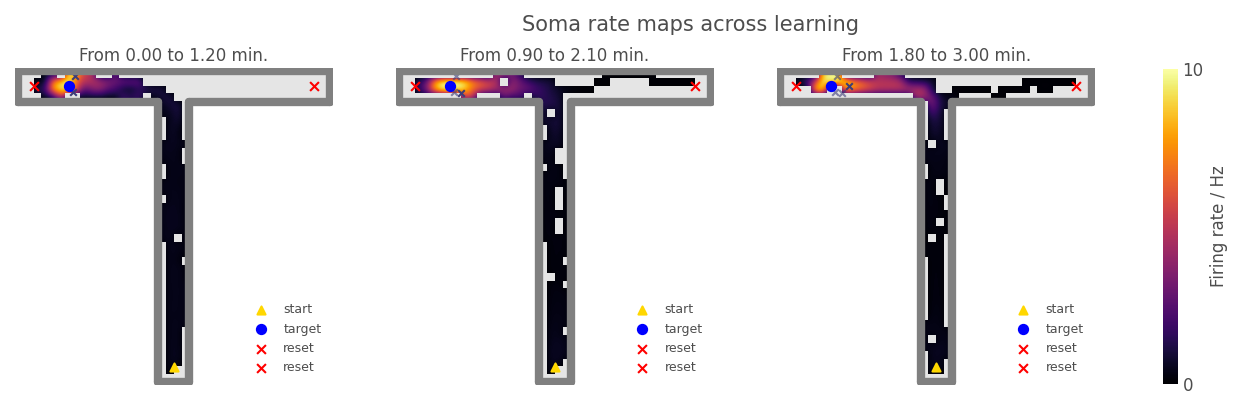

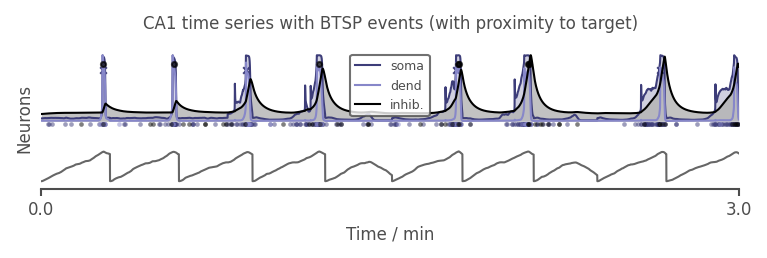

In [25]:
CA3_PC_params = params_util.get_CA3_PC_params(
    environment="tmaze", 
    n=177, # 40, # for one column and one row 
    place_cell_centres="uniform_jitter"
)

Env, Ag, ECs, CA3_PCs, CA1s = run_manager.learn_T_maze_BTSP(
    env_params, 
    Ag_params, 
    CA3_PC_params, 
    CA1_params, 
    num_rewards=12, 
    max_num_steps=6000, 
    weight_recording_freq=100, 
    use_Hebbian=False,
    BTSP_after_num_target_reaches=2, # ignored if 2-compartment
    two_compartment=True
)

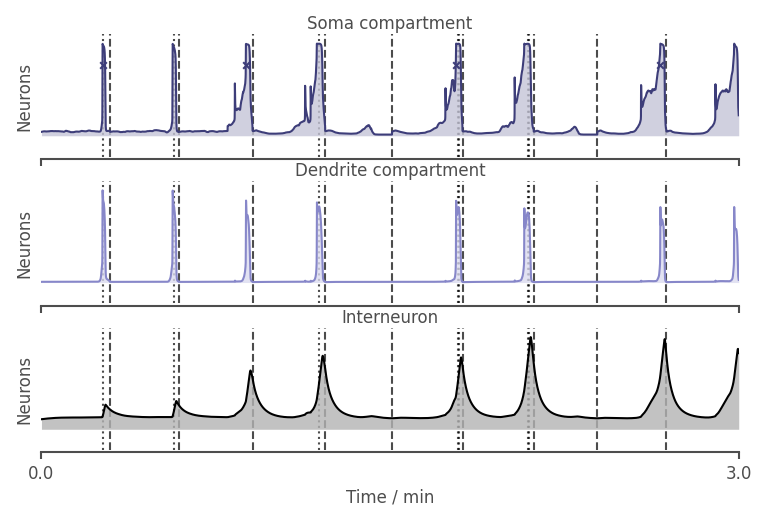

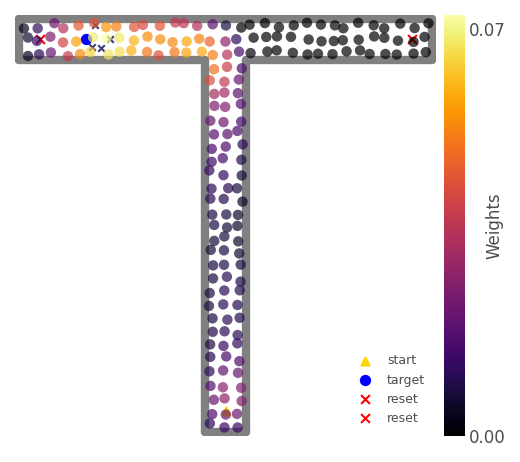

In [26]:
ax_time = CA1s.plot_rate_timeseries(separate_axes=True)

fig_weights, ax_weights = plt.subplots(figsize=[3, 3])
plot_util.plot_2D_input_place_cell_weights(CA1s.SomaCompartment, ax=ax_weights, s=25, plot_BTSP_events=True);

In [27]:
INHIBIT_WEIGHT = 5.0 # too high

In [28]:
DT = params_util.DT

env_params = params_util.get_env_params(environment="tmaze")

Ag_params = params_util.get_agent_params(
    environment="tmaze", dt=DT, left_arm_prop=0.8
)

CA3_PC_params = params_util.get_CA3_PC_params(
    environment="tmaze", place_cell_centres="uniform"
)

CA1_params = params_util.get_CA1_params(
    n=1, environment="tmaze", 
    two_compartment=True, BTSP=True,
    soma_BTSP_lr_fact=400,
    inhibit_weight=INHIBIT_WEIGHT
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6000/6000 [00:09<00:00, 652.51it/s]


Only reached the reward 10 times (target: 12).
Trajectory lengths (10) to date: 18.00 +/- 1.75 sec each
Trajectory lengths (10) to date: 600.00 +/- 58.35 steps each


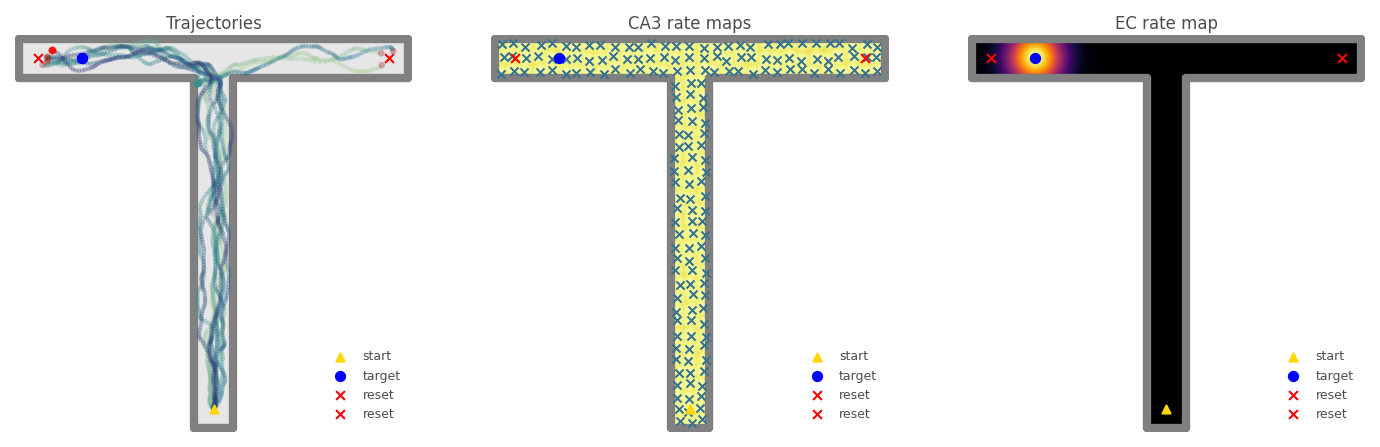

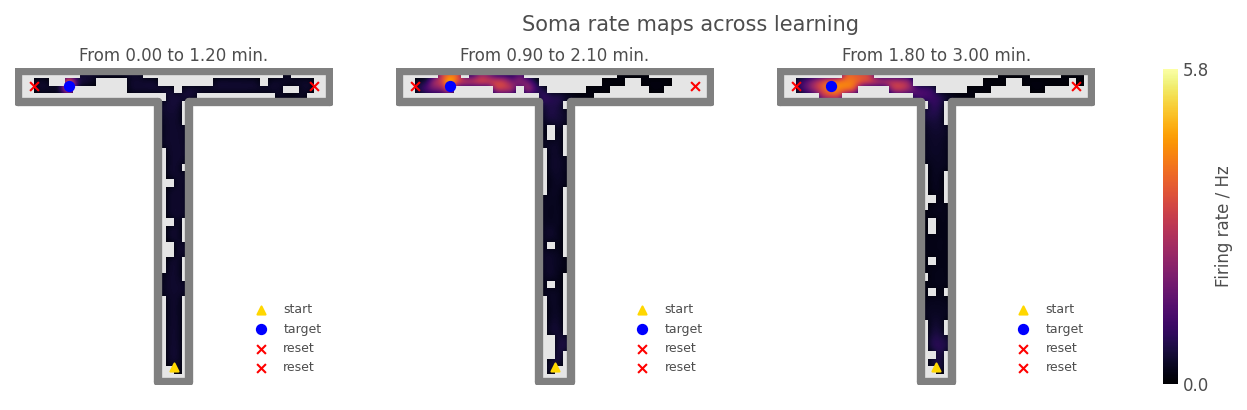

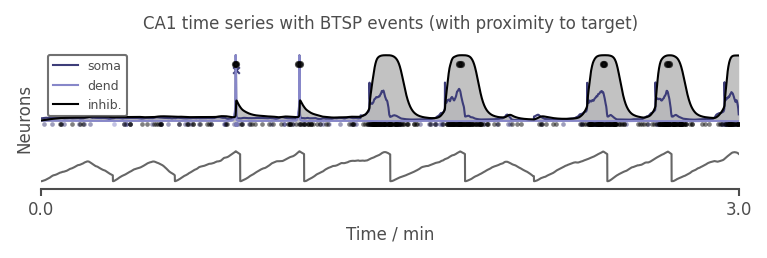

In [29]:
CA3_PC_params = params_util.get_CA3_PC_params(
    environment="tmaze", 
    n=177, # 40, # for one column and one row 
    place_cell_centres="uniform_jitter"
)

Env, Ag, ECs, CA3_PCs, CA1s = run_manager.learn_T_maze_BTSP(
    env_params, 
    Ag_params, 
    CA3_PC_params, 
    CA1_params, 
    num_rewards=12, 
    max_num_steps=6000, 
    weight_recording_freq=100, 
    use_Hebbian=False,
    BTSP_after_num_target_reaches=2, # ignored if 2-compartment
    two_compartment=True
)

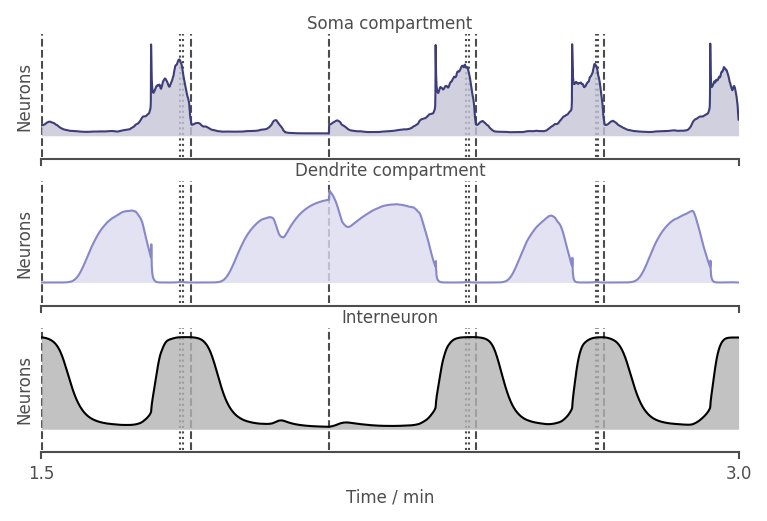

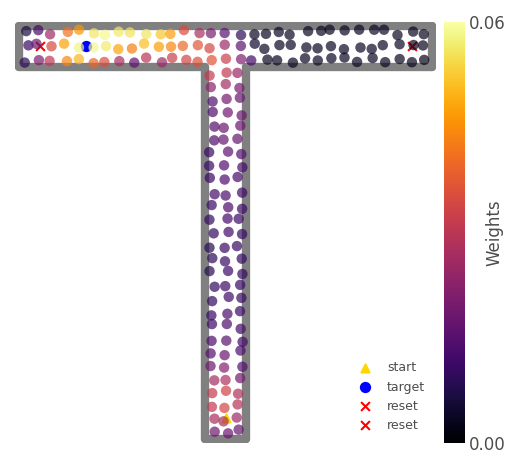

In [30]:
ax_time = CA1s.plot_rate_timeseries(separate_axes=True, t_start=90)

fig_weights, ax_weights = plt.subplots(figsize=[3, 3])
plot_util.plot_2D_input_place_cell_weights(CA1s.SomaCompartment, ax=ax_weights, s=25, plot_BTSP_events=True);